In [1]:
# Initialize your API key
!pip install cohere
import os
# Initialize your Cohere API key
import cohere
cohere_api_key = "FFXRBOTmrDWR1ULdRRo1LhM0IcGOe4kYhpghjRP5"
# Initialize the Cohere client
cohere_client = cohere.Client(cohere_api_key)



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Update Cohere to the latest version
from importlib.metadata import version
try:
    assert version('cohere') == 'latest'  # 'latest' placeholder; actual version check isn't supported by importlib.metadata
except:
    !pip install --upgrade cohere  # This will install the latest version of Cohere
import cohere


In [ ]:
# Run this cell to install the latest versions of ChromaDB and pysqlite3 if desired
from importlib.metadata import version
try:
    assert version('chromadb')  # No specific version needed, install latest
except:
    !pip install --upgrade chromadb  # Installs the latest version of ChromaDB

try:
    assert version('pysqlite3')  # No specific version needed, install latest
except:
    !pip install --upgrade pysqlite3-binary  # Installs the latest version of pysqlite3

__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb


In [ ]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("/content/sample_data/data/womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


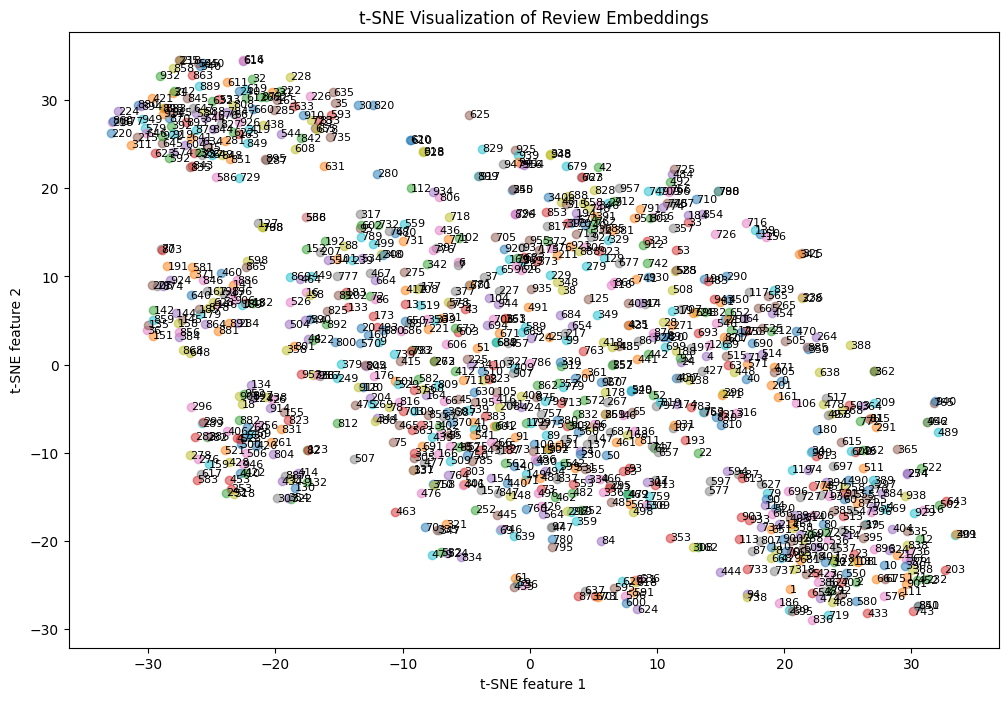

['Absolutely wonderful - silky and sexy and comfortable', 'I have already worn this several times. it is very flattering, lightweight, and easy to wear. dressy but also very soft and comfortable.', 'This top is stunning. the colors are vivid and it is extremely cozy and soft. however it seems delicate and would need to only be worn once in a while. it is not an everyday top. the material has a cotton candy like appearance. it really is unique and one of a kind.']


In [16]:
# Import required libraries
import os
import cohere
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import chromadb
from scipy.spatial import distance
from chromadb.utils.embedding_functions import CohereEmbeddingFunction

# Initialize your Cohere API key
cohere_api_key = "FFXRBOTmrDWR1ULdRRo1LhM0IcGOe4kYhpghjRP5"
client = cohere.Client(api_key=cohere_api_key)

# Set the embedding model (use "embed-english-v2.0" or another model as needed)
EMBEDDING_MODEL = "embed-english-v2.0"

# Load the dataset
reviews = pd.read_csv("/content/sample_data/data/womens_clothing_e-commerce_reviews.csv")
review_texts = reviews["Review Text"].dropna().tolist()

# Generate embeddings for reviews using Cohere API
response = client.embed(texts=review_texts, model=EMBEDDING_MODEL)
embeddings = response.embeddings

# Apply t-SNE for dimensionality reduction (for visualization only)
def apply_tsne(embeddings):
    tsne = TSNE(n_components=2, random_state=0)
    return tsne.fit_transform(embeddings)

embeddings_2d = apply_tsne(np.array(embeddings))

# Plotting the results of t-SNE
def plot_tsne(tsne_results):
    plt.figure(figsize=(12, 8))
    for i, point in enumerate(tsne_results):
        plt.scatter(point[0], point[1], alpha=0.5)
        plt.text(point[0], point[1], str(i), fontsize=8, verticalalignment='center')
    plt.title("t-SNE Visualization of Review Embeddings")
    plt.xlabel("t-SNE feature 1")
    plt.ylabel("t-SNE feature 2")
    plt.show()

plot_tsne(embeddings_2d)

# Define topics
categories = ["Quality", "Fit", "Style", "Comfort"]

# Create embeddings for all categories in one API call
category_response = client.embed(texts=categories, model=EMBEDDING_MODEL)
category_embeddings = category_response.embeddings

# Function to categorize feedback
def categorize_feedback(text_embedding, category_embeddings):
    similarities = [{"distance": distance.cosine(text_embedding, cat_emb), "index": i}
                    for i, cat_emb in enumerate(category_embeddings)]
    closest = min(similarities, key=lambda x: x["distance"])
    return categories[closest["index"]]

# Categorize feedback
feedback_categories = [categorize_feedback(embedding, category_embeddings) for embedding in embeddings]

# Initialize ChromaDB instance for vector storage
client_db = chromadb.PersistentClient()

# Define vector database
collection_name = "review_embeddings"

# Attempt to delete the collection if it exists to avoid conflicts
try:
    client_db.delete_collection(name=collection_name)
except Exception as e:
    print(f"Could not delete collection (might not exist yet): {e}")

# Create the new collection
review_embeddings_db = client_db.create_collection(
    name=collection_name,
    embedding_function=CohereEmbeddingFunction(api_key=cohere_api_key)
)

# Store embeddings inside vector database
review_embeddings_db.add(
    documents=review_texts,
    embeddings=embeddings,  # Use original 4096-dimensional embeddings here
    ids=[str(i) for i in range(len(review_texts))]
)

# Function for similarity search using vector db query function
def find_similar_reviews(input_text, collection, n=3):
    # Generate embedding for input text using Cohere
    input_embedding = client.embed(texts=[input_text], model=EMBEDDING_MODEL).embeddings[0]

    # Query the collection for similar reviews
    results = collection.query(
        query_embeddings=[input_embedding],
        n_results=n
    )
    return results

# Example feedback and finding similar feedback
example_review = "Absolutely wonderful - silky and sexy and comfortable"
most_similar_reviews = find_similar_reviews(example_review, review_embeddings_db, 3)
print(most_similar_reviews['documents'][0])

# Clean up
client_db.delete_collection(name=collection_name)
